# CSAO Evaluation Results & Insights Notebook

This notebook provides a structured evaluation package for:

1. **Performance metrics on holdout test set**
2. **Error analysis and insights**
3. **Comparison with baseline approaches**

It reads artifacts generated by your existing pipeline (`output/`, `data_pipeline/data/featured/`, etc.) and produces presentation-ready tables/charts.



## 1. Setup & Paths


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

# Resolve project root robustly from notebook location
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD
for p in [CWD, *CWD.parents]:
    if (p / 'data_pipeline').exists() and (p / 'src').exists():
        PROJECT_ROOT = p
        break

OUTPUT_DIR = PROJECT_ROOT / 'output'
DATA_DIR = PROJECT_ROOT / 'data_pipeline' / 'data'

BASELINE_EVAL_JSON = OUTPUT_DIR / 'baseline_output' / 'evaluation_summary.json'
CYCLE2_SUMMARY_JSON = OUTPUT_DIR / 'cycle2' / 'cycle2_summary.json'
CYCLE3_SUMMARY_JSON = OUTPUT_DIR / 'cycle3' / 'cycle3_summary.json'
ERROR_SUMMARY_JSON = OUTPUT_DIR / 'error_analysis' / 'summary_report.json'
SEGMENT_METRICS_CSV = OUTPUT_DIR / 'error_analysis' / 'segment_metrics.csv'
FEATURE_IMPORTANCE_CSV = OUTPUT_DIR / 'error_analysis' / 'feature_importance.csv'
CALIBRATION_CSV = OUTPUT_DIR / 'error_analysis' / 'calibration_curve.csv'
ERROR_CASES_PARQUET = OUTPUT_DIR / 'error_analysis' / 'error_cases.parquet'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('BASELINE_EVAL_JSON exists:', BASELINE_EVAL_JSON.exists())
print('CYCLE2_SUMMARY_JSON exists:', CYCLE2_SUMMARY_JSON.exists())
print('CYCLE3_SUMMARY_JSON exists:', CYCLE3_SUMMARY_JSON.exists())
print('ERROR_SUMMARY_JSON exists:', ERROR_SUMMARY_JSON.exists())


PROJECT_ROOT = /Users/aman/Desktop/CSAO_2.0
BASELINE_EVAL_JSON exists: True
CYCLE2_SUMMARY_JSON exists: True
CYCLE3_SUMMARY_JSON exists: True
ERROR_SUMMARY_JSON exists: True


## 2. Utility Loaders


In [2]:
def safe_load_json(path: Path, default):
    if not path.exists():
        return default
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f'Failed to load JSON {path}: {e}')
        return default


def safe_read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f'Failed to load CSV {path}: {e}')
        return pd.DataFrame()


def safe_read_parquet(path: Path, columns=None) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_parquet(path, columns=columns)
    except Exception:
        try:
            return pd.read_parquet(path)
        except Exception as e:
            print(f'Failed to load Parquet {path}: {e}')
            return pd.DataFrame()


## 3. Load Evaluation Artifacts


In [3]:
baseline_eval = safe_load_json(BASELINE_EVAL_JSON, [])
cycle2_summary = safe_load_json(CYCLE2_SUMMARY_JSON, {})
cycle3_summary = safe_load_json(CYCLE3_SUMMARY_JSON, {})
error_summary = safe_load_json(ERROR_SUMMARY_JSON, {})
segment_metrics = safe_read_csv(SEGMENT_METRICS_CSV)
feature_importance = safe_read_csv(FEATURE_IMPORTANCE_CSV)
calibration_curve = safe_read_csv(CALIBRATION_CSV)
error_cases = safe_read_parquet(ERROR_CASES_PARQUET)

print('baseline_eval rows:', len(baseline_eval) if isinstance(baseline_eval, list) else 'N/A')
print('cycle2 keys:', list(cycle2_summary.keys())[:10] if isinstance(cycle2_summary, dict) else 'N/A')
print('cycle3 keys:', list(cycle3_summary.keys())[:10] if isinstance(cycle3_summary, dict) else 'N/A')
print('error_summary keys:', list(error_summary.keys())[:10] if isinstance(error_summary, dict) else 'N/A')
print('segment_metrics shape:', segment_metrics.shape)
print('feature_importance shape:', feature_importance.shape)
print('calibration_curve shape:', calibration_curve.shape)
print('error_cases shape:', error_cases.shape)


baseline_eval rows: 4
cycle2 keys: ['seed', 'top_k', 'rows', 'features', 'best_model', 'metrics_test', 'best_trial', 'runtime_sec']
cycle3 keys: ['trials', 'best_trial', 'best_val_ndcg', 'comparison', 'impact']
error_summary keys: ['runtime_sec', 'data_source', 'top_k_eval', 'best_model', 'global_metrics', 'retrieval_diagnosis', 'worst_segments', 'top_features', 'notes']
segment_metrics shape: (21, 11)
feature_importance shape: (34, 4)
calibration_curve shape: (10, 5)
error_cases shape: (1000, 10)


## 4. Performance Metrics on Holdout Test Set

This section consolidates test metrics from available artifacts.



In [4]:
# Baseline summary table from output/baseline_output/evaluation_summary.json
if isinstance(baseline_eval, list) and baseline_eval:
    baseline_eval_df = pd.DataFrame(baseline_eval)
else:
    baseline_eval_df = pd.DataFrame(columns=['model', 'split', 'NDCG@10', 'MAP', 'MRR', 'Precision@10', 'Recall@10', 'AUC'])

baseline_eval_df


,model,split,NDCG@10,MAP,MRR,Precision@10,Recall@10,AUC
0,LightGBM,val,0.658599,0.658117,0.658834,0.656537,0.659325,0.795083
1,LightGBM,test,0.658388,0.657861,0.658651,0.655945,0.659185,0.793614
2,XGBoost,val,0.658574,0.658105,0.658861,0.656519,0.659265,0.800696
3,XGBoost,test,0.658427,0.657891,0.658705,0.655956,0.659224,0.799077


In [5]:
test_metrics_baseline = baseline_eval_df[baseline_eval_df.get('split', pd.Series(dtype=str)).astype(str).str.lower() == 'test'].copy()
if not test_metrics_baseline.empty:
    cols = ['model', 'NDCG@10', 'MAP', 'MRR', 'Precision@10', 'Recall@10', 'AUC']
    test_metrics_baseline = test_metrics_baseline[[c for c in cols if c in test_metrics_baseline.columns]]

test_metrics_baseline


,model,NDCG@10,MAP,MRR,Precision@10,Recall@10,AUC
1,LightGBM,0.658388,0.657861,0.658651,0.655945,0.659185,0.793614
3,XGBoost,0.658427,0.657891,0.658705,0.655956,0.659224,0.799077


In [6]:
# Cycle 2 tuned metrics (test)
cycle2_metrics = []
if isinstance(cycle2_summary, dict):
    mt = cycle2_summary.get('metrics_test', {})
    for model_name, vals in mt.items():
        row = {'model': model_name, 'source': 'cycle2_tuned'}
        row.update(vals)
        cycle2_metrics.append(row)
cycle2_df = pd.DataFrame(cycle2_metrics)
cycle2_df


,model,source,NDCG@10,MAP,MRR,Precision@10,Recall@10,AUC
0,LightGBM,cycle2_tuned,0.711590,0.607826,0.762536,0.249659,0.866026,0.802519
1,XGBoost,cycle2_tuned,0.710361,0.607654,0.762021,0.248888,0.863368,0.802186


In [7]:
# Cycle 3 neural metrics (test)
cycle3_neural_df = pd.DataFrame()
if isinstance(cycle3_summary, dict):
    comp = cycle3_summary.get('comparison', {})
    nm = comp.get('neural_metrics_test', {}) if isinstance(comp, dict) else {}
    if nm:
        row = {'model': 'NeuralRanker', 'source': 'cycle3_neural'}
        row.update(nm)
        cycle3_neural_df = pd.DataFrame([row])
cycle3_neural_df


,model,source,NDCG@10,MAP,MRR,Precision@10,Recall@10,eligible_sessions,AUC
0,NeuralRanker,cycle3_neural,0.340422,0.272753,0.329152,0.158274,0.569409,9288.0,0.509274


In [8]:
# Unified holdout comparison table
frames = []
if not test_metrics_baseline.empty:
    x = test_metrics_baseline.copy()
    x['source'] = 'baseline_eval'
    frames.append(x)
if not cycle2_df.empty:
    frames.append(cycle2_df)
if not cycle3_neural_df.empty:
    frames.append(cycle3_neural_df)

holdout_comparison = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
metric_cols = ['NDCG@10', 'MAP', 'MRR', 'Precision@10', 'Recall@10', 'AUC']
for c in metric_cols:
    if c in holdout_comparison.columns:
        holdout_comparison[c] = pd.to_numeric(holdout_comparison[c], errors='coerce')

holdout_comparison.sort_values(['source', 'model']) if not holdout_comparison.empty else holdout_comparison


,model,NDCG@10,MAP,MRR,Precision@10,Recall@10,AUC,source,eligible_sessions
0,LightGBM,0.658388,0.657861,0.658651,0.655945,0.659185,0.793614,baseline_eval,NaN
1,XGBoost,0.658427,0.657891,0.658705,0.655956,0.659224,0.799077,baseline_eval,NaN
2,LightGBM,0.711590,0.607826,0.762536,0.249659,0.866026,0.802519,cycle2_tuned,NaN
3,XGBoost,0.710361,0.607654,0.762021,0.248888,0.863368,0.802186,cycle2_tuned,NaN
4,NeuralRanker,0.340422,0.272753,0.329152,0.158274,0.569409,0.509274,cycle3_neural,9288.0


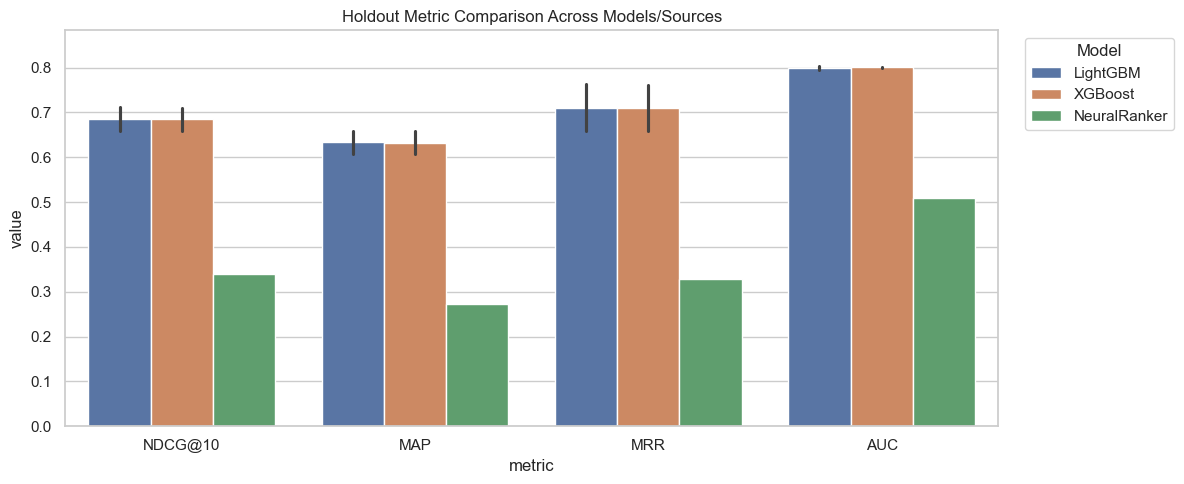

In [9]:
# Visual comparison for key ranking metrics
if holdout_comparison.empty:
    print('No holdout metrics found.')
else:
    plot_df = holdout_comparison.melt(
        id_vars=[c for c in ['model', 'source'] if c in holdout_comparison.columns],
        value_vars=[c for c in ['NDCG@10', 'MAP', 'MRR', 'AUC'] if c in holdout_comparison.columns],
        var_name='metric',
        value_name='value'
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_df, x='metric', y='value', hue='model')
    plt.title('Holdout Metric Comparison Across Models/Sources')
    plt.ylim(0, min(1.0, max(0.05, plot_df['value'].max() * 1.1 if len(plot_df) else 1.0)))
    plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


### Key Performance Insights (Auto-Generated)


In [10]:
insights = []
if not holdout_comparison.empty and 'NDCG@10' in holdout_comparison.columns:
    best_ndcg_row = holdout_comparison.loc[holdout_comparison['NDCG@10'].idxmax()]
    insights.append(f"Best NDCG@10: {best_ndcg_row['NDCG@10']:.4f} ({best_ndcg_row['model']} | {best_ndcg_row.get('source', 'N/A')})")
if not holdout_comparison.empty and 'AUC' in holdout_comparison.columns:
    best_auc_row = holdout_comparison.loc[holdout_comparison['AUC'].idxmax()]
    insights.append(f"Best AUC: {best_auc_row['AUC']:.4f} ({best_auc_row['model']} | {best_auc_row.get('source', 'N/A')})")

if cycle2_df.shape[0] >= 2 and {'model','NDCG@10'}.issubset(cycle2_df.columns):
    c2 = cycle2_df.set_index('model')['NDCG@10']
    if 'LightGBM' in c2.index and 'XGBoost' in c2.index:
        diff = float(c2['LightGBM'] - c2['XGBoost'])
        insights.append(f"Cycle 2 tuned LightGBM - XGBoost NDCG@10 difference: {diff:+.4f}")

if not cycle3_neural_df.empty and not cycle2_df.empty:
    try:
        c2_best = float(cycle2_df['NDCG@10'].max())
        c3 = float(cycle3_neural_df['NDCG@10'].iloc[0])
        insights.append(f"Neural vs best Cycle 2 NDCG@10 delta: {c3 - c2_best:+.4f}")
    except Exception:
        pass

for i, line in enumerate(insights, 1):
    print(f"{i}. {line}")

if not insights:
    print('No automatic insights could be generated from current artifacts.')


1. Best NDCG@10: 0.7116 (LightGBM | cycle2_tuned)
2. Best AUC: 0.8025 (LightGBM | cycle2_tuned)
3. Cycle 2 tuned LightGBM - XGBoost NDCG@10 difference: +0.0012
4. Neural vs best Cycle 2 NDCG@10 delta: -0.3712


## 5. Error Analysis and Insights

This section uses `output/error_analysis/*` artifacts and highlights where the model struggles.



In [11]:
# Error analysis summary payload
error_summary


{'runtime_sec': 9.02081462500064,
 'data_source': 'processed',
 'top_k_eval': 10,
 'best_model': 'XGBoost',
 'global_metrics': [{'model': 'LightGBM',
   'split': 'val',
   'NDCG@10': 0.6190464149662578,
   'MAP': 0.6113350630968531,
   'MRR': 0.6220710811214436,
   'Precision@10': 0.5938144902808359,
   'Recall@10': 0.6349538448598524,
   'AUC': 0.6264496481023261},
  {'model': 'XGBoost',
   'split': 'val',
   'NDCG@10': 0.6193245923739151,
   'MAP': 0.6118470998320914,
   'MRR': 0.6230506877267606,
   'Precision@10': 0.5936168327330512,
   'Recall@10': 0.6342844726678862,
   'AUC': 0.6234389874645616},
  {'model': 'LightGBM',
   'split': 'test',
   'NDCG@10': 0.6223987526099894,
   'MAP': 0.6149385738280052,
   'MRR': 0.6252312987703804,
   'Precision@10': 0.5975672599643869,
   'Recall@10': 0.6380890554869153,
   'AUC': 0.6253155756570539},
  {'model': 'XGBoost',
   'split': 'test',
   'NDCG@10': 0.6225174491377972,
   'MAP': 0.6152615213374659,
   'MRR': 0.6261384022781212,
   'Prec

In [12]:
# Global metrics from error analysis
global_metrics_df = pd.DataFrame(error_summary.get('global_metrics', [])) if isinstance(error_summary, dict) else pd.DataFrame()
global_metrics_df


,model,split,NDCG@10,MAP,MRR,Precision@10,Recall@10,AUC
0,LightGBM,val,0.619046,0.611335,0.622071,0.593814,0.634954,0.626450
1,XGBoost,val,0.619325,0.611847,0.623051,0.593617,0.634284,0.623439
2,LightGBM,test,0.622399,0.614939,0.625231,0.597567,0.638089,0.625316
3,XGBoost,test,0.622517,0.615262,0.626138,0.597349,0.637342,0.622373


In [13]:
# Retrieval diagnosis
retrieval_diag = error_summary.get('retrieval_diagnosis', {}) if isinstance(error_summary, dict) else {}
retrieval_diag


{'candidate_pool_recall': 1.0,
 'missing_positive_pct': 0.0,
 'ranking_recall@10': 0.30012862455610545}

In [15]:
# Segment metrics overview
if segment_metrics.empty:
    print('segment_metrics.csv not available')
else:
    display_cols = [c for c in ['model','segment_type','segment_value','rows','positive_rate','NDCG@10','MAP','MRR','Precision@10','Recall@10','AUC'] if c in segment_metrics.columns]
    seg_show = segment_metrics[display_cols].copy()
    seg_show.head(20)


In [16]:
# Worst segments by NDCG@10 (if available)
if segment_metrics.empty or 'NDCG@10' not in segment_metrics.columns:
    print('No segment NDCG data found.')
else:
    tmp = segment_metrics.copy()
    tmp['NDCG@10'] = pd.to_numeric(tmp['NDCG@10'], errors='coerce')
    worst = tmp.sort_values('NDCG@10', ascending=True).head(10)
    cols = [c for c in ['model','segment_type','segment_value','rows','positive_rate','NDCG@10','AUC'] if c in worst.columns]
    worst[cols]


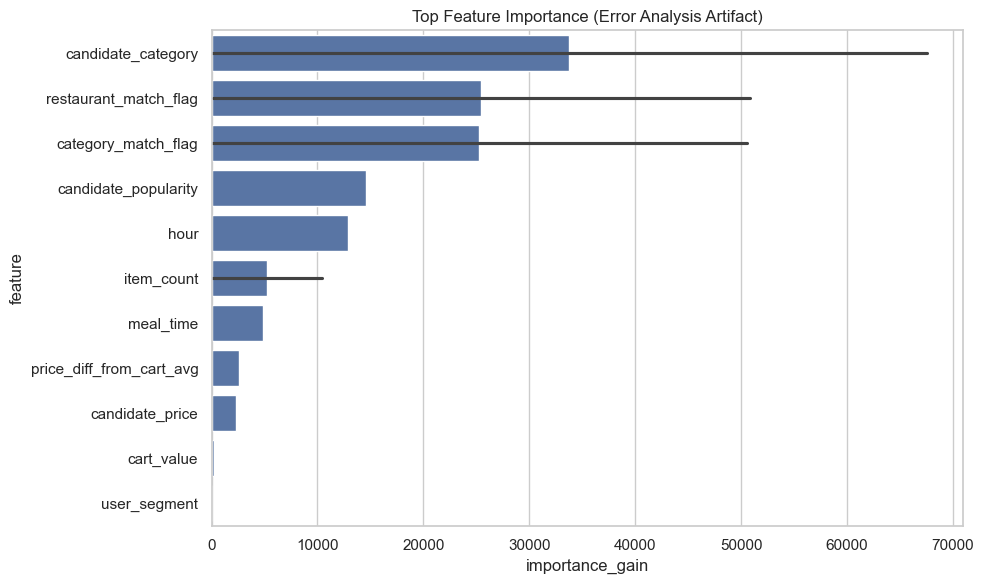

,feature,importance_gain
0,candidate_category,67529.053514
1,restaurant_match_flag,50796.513916
2,category_match_flag,50529.805928
3,candidate_popularity,14551.193609
4,hour,12882.743966
5,item_count,10400.169893
6,meal_time,4901.306126
7,price_diff_from_cart_avg,2626.418794
8,candidate_price,2354.191890
9,cart_value,273.403301


In [17]:
# Top feature importance from error analysis (if available)
if feature_importance.empty:
    print('feature_importance.csv not available')
else:
    fi = feature_importance.copy()
    name_col = 'feature' if 'feature' in fi.columns else (fi.columns[0] if len(fi.columns) > 0 else None)
    imp_col = None
    for c in ['importance_gain','importance','gain']:
        if c in fi.columns:
            imp_col = c
            break
    if name_col and imp_col:
        fi = fi[[name_col, imp_col]].dropna().copy()
        fi[imp_col] = pd.to_numeric(fi[imp_col], errors='coerce')
        fi = fi.sort_values(imp_col, ascending=False).head(15)
        plt.figure(figsize=(10, 6))
        sns.barplot(data=fi, x=imp_col, y=name_col)
        plt.title('Top Feature Importance (Error Analysis Artifact)')
        plt.tight_layout()
        plt.show()
        display(fi)
    else:
        print('Could not infer feature/importance columns in feature_importance.csv')


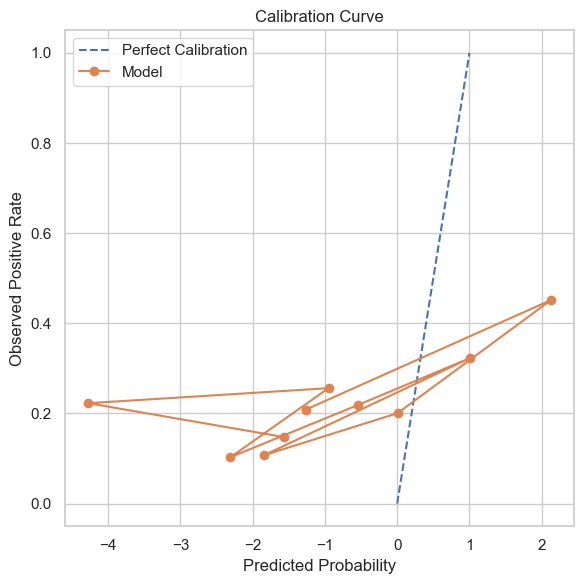

In [18]:
# Calibration curve (if available)
if calibration_curve.empty:
    print('calibration_curve.csv not available')
else:
    cdf = calibration_curve.copy()
    pred_col = 'mean_pred' if 'mean_pred' in cdf.columns else (cdf.columns[0] if len(cdf.columns) > 0 else None)
    act_col = 'mean_actual' if 'mean_actual' in cdf.columns else (cdf.columns[1] if len(cdf.columns) > 1 else None)
    if pred_col and act_col:
        cdf[pred_col] = pd.to_numeric(cdf[pred_col], errors='coerce')
        cdf[act_col] = pd.to_numeric(cdf[act_col], errors='coerce')
        plt.figure(figsize=(6, 6))
        plt.plot([0,1], [0,1], '--', label='Perfect Calibration')
        plt.plot(cdf[pred_col], cdf[act_col], marker='o', label='Model')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Observed Positive Rate')
        plt.title('Calibration Curve')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('Could not infer calibration columns.')


### Error Analysis Insights (Suggested Talking Points)

- If **candidate_pool_recall is high** but ranking recall@K is moderate, retrieval is likely not the main bottleneck; ranking order quality is.
- Worst segments help identify where feature coverage or model calibration is weak.
- Feature importance should align with domain logic (category/restaurant match, popularity, time/context).
- Calibration mismatch indicates score confidence may need post-processing (e.g., isotonic/platt or segment calibration).



## 6. Comparison with Baseline Approaches

This section explicitly compares baseline models against neural approaches and summarizes trade-offs.



In [19]:
comparison_rows = []

# Cycle 2 baseline models
if not cycle2_df.empty:
    for _, r in cycle2_df.iterrows():
        comparison_rows.append({
            'family': 'Baseline',
            'model': r.get('model'),
            'source': 'cycle2_tuned',
            'NDCG@10': r.get('NDCG@10'),
            'MAP': r.get('MAP'),
            'MRR': r.get('MRR'),
            'AUC': r.get('AUC'),
        })

# Cycle 3 neural
if not cycle3_neural_df.empty:
    r = cycle3_neural_df.iloc[0]
    comparison_rows.append({
        'family': 'Neural',
        'model': r.get('model', 'NeuralRanker'),
        'source': 'cycle3_neural',
        'NDCG@10': r.get('NDCG@10'),
        'MAP': r.get('MAP'),
        'MRR': r.get('MRR'),
        'AUC': r.get('AUC'),
    })

comparison_df = pd.DataFrame(comparison_rows)
for c in ['NDCG@10','MAP','MRR','AUC']:
    if c in comparison_df.columns:
        comparison_df[c] = pd.to_numeric(comparison_df[c], errors='coerce')

comparison_df


,family,model,source,NDCG@10,MAP,MRR,AUC
0,Baseline,LightGBM,cycle2_tuned,0.711590,0.607826,0.762536,0.802519
1,Baseline,XGBoost,cycle2_tuned,0.710361,0.607654,0.762021,0.802186
2,Neural,NeuralRanker,cycle3_neural,0.340422,0.272753,0.329152,0.509274


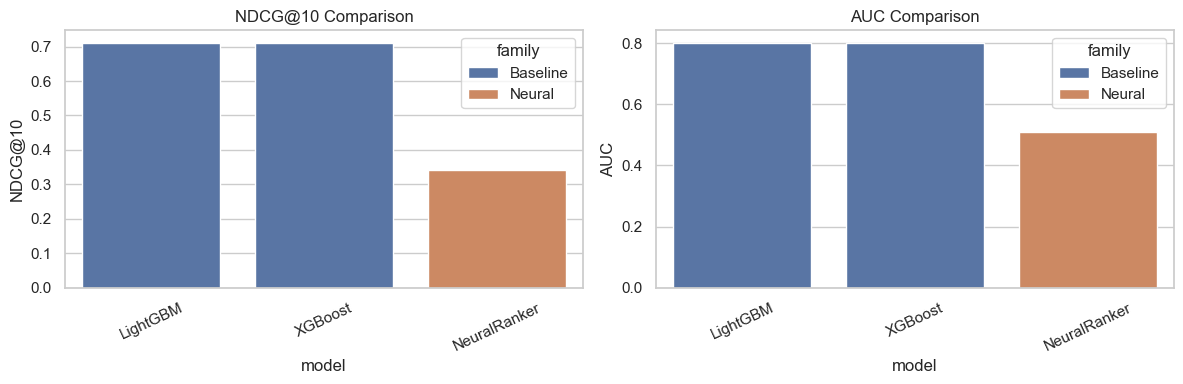

In [20]:
if comparison_df.empty:
    print('No comparison data available.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=comparison_df, x='model', y='NDCG@10', hue='family', ax=axes[0])
    axes[0].set_title('NDCG@10 Comparison')
    axes[0].tick_params(axis='x', rotation=25)

    sns.barplot(data=comparison_df, x='model', y='AUC', hue='family', ax=axes[1])
    axes[1].set_title('AUC Comparison')
    axes[1].tick_params(axis='x', rotation=25)

    plt.tight_layout()
    plt.show()


In [21]:
# Auto summary block for report/presentation
summary_lines = []

if not comparison_df.empty:
    best_ndcg = comparison_df.loc[comparison_df['NDCG@10'].idxmax()]
    summary_lines.append(f"Best NDCG@10 model: {best_ndcg['model']} ({best_ndcg['NDCG@10']:.4f})")

    baseline_best = comparison_df[comparison_df['family'] == 'Baseline']['NDCG@10'].max() if 'family' in comparison_df.columns else np.nan
    neural_best = comparison_df[comparison_df['family'] == 'Neural']['NDCG@10'].max() if 'family' in comparison_df.columns else np.nan
    if pd.notna(baseline_best) and pd.notna(neural_best):
        summary_lines.append(f"Neural vs baseline NDCG@10 delta: {neural_best - baseline_best:+.4f}")

if isinstance(error_summary, dict) and 'retrieval_diagnosis' in error_summary:
    rd = error_summary['retrieval_diagnosis']
    summary_lines.append(
        f"Retrieval recall diagnostic: candidate_pool_recall={rd.get('candidate_pool_recall', 'N/A')}, ranking_recall@10={rd.get('ranking_recall@10', 'N/A')}"
    )

print('=== Evaluation Summary for Submission ===')
for s in summary_lines:
    print('-', s)

if not summary_lines:
    print('Insufficient artifacts found; run baseline/error-analysis pipelines first.')


=== Evaluation Summary for Submission ===
- Best NDCG@10 model: LightGBM (0.7116)
- Neural vs baseline NDCG@10 delta: -0.3712
- Retrieval recall diagnostic: candidate_pool_recall=1.0, ranking_recall@10=0.30012862455610545


## 7. Export Ready Tables (Optional)

Run this cell to save consolidated tables for report/ppt integration.



In [22]:
EXPORT_DIR = PROJECT_ROOT / 'reports' / 'evaluation_insights'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if 'holdout_comparison' in globals() and isinstance(holdout_comparison, pd.DataFrame) and not holdout_comparison.empty:
    holdout_comparison.to_csv(EXPORT_DIR / 'holdout_comparison.csv', index=False)
if 'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame) and not comparison_df.empty:
    comparison_df.to_csv(EXPORT_DIR / 'baseline_vs_neural_comparison.csv', index=False)
if isinstance(global_metrics_df, pd.DataFrame) and not global_metrics_df.empty:
    global_metrics_df.to_csv(EXPORT_DIR / 'error_analysis_global_metrics.csv', index=False)

print('Exported files to:', EXPORT_DIR)
for p in sorted(EXPORT_DIR.glob('*')):
    print('-', p.name)


Exported files to: /Users/aman/Desktop/CSAO_2.0/reports/evaluation_insights
- baseline_vs_neural_comparison.csv
- error_analysis_global_metrics.csv
- holdout_comparison.csv
